In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from SVD_analysis.src.fitting_utils import fit_function, allometric, arrhenius

In [2]:
size=15
params = {'legend.fontsize': 'large',
          'axes.labelsize': size,
          'axes.titlesize': size,
          'xtick.labelsize': size,
          'ytick.labelsize': size,
          'axes.titlepad': 5,
          'lines.linewidth': 2,
          'figure.dpi': 100}
plt.rcParams.update(params)


In [3]:
def asymptotic(x, a, b, n):
    y = a * x ** n  / (x ** n + b**n)
    y[y>39] = 39.
    return y


def asymptotic_b(x, b):
    n = 0.65
    a = 65
    y = a * x ** n  / (x ** n + b**n)
    y[y>39] = 39.
    return y

def exp_asymptotic(x,l):
    return 39*(1 - np.exp(-l * x))

In [4]:
df = pd.read_csv('astronomical_time_vs_developmental_time_summary_df.csv', index_col=0)

# print(df)

/var/folders/yn/r99j3qy962lg5cwmzc1dpqg40000gn/T/ipykernel_13050/2908197753.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  viridis_group = plt.cm.get_cmap('viridis', 4)


['17' '21-27' '22' '26+/-1' '27' '32']
17 [307.94747394]
21-27 [139.31626058]
22 [185.5566546]
26+/-1 [105.14116696]
27 [108.57067939]
32 [82.95044689]
Tc: 12.075073579737126
Allometric model: [0.00900562 1.95726787]
Arrhenius model: [8.80866123e-03 2.23520412e+01]


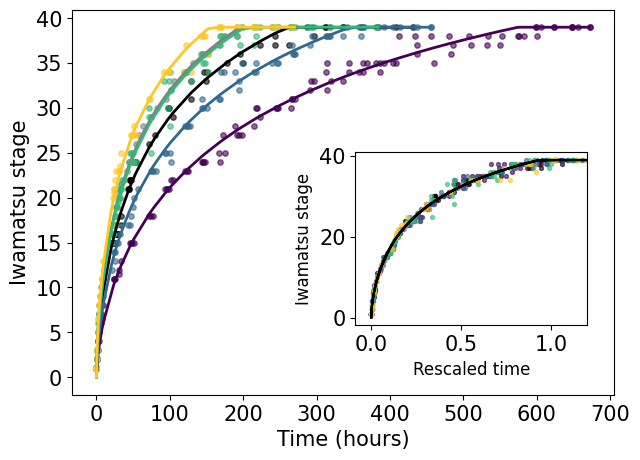

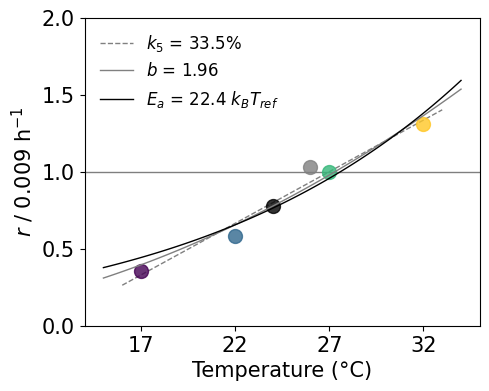

0.0670020053594601 0.00627461768323679


In [5]:
viridis_group = plt.cm.get_cmap('viridis', 4)
group_colors = viridis_group(np.linspace(0, 1, 4))
type_color_dict = {'17': group_colors[0], '22': group_colors[1], '27': group_colors[2], '32': '#FFC726',
                   '35': 'brown', '21-27': 'k', '15-32':'lightcoral','17-34':'lightcoral', '26+/-1':'gray'}

type_temp_dict = {'17': 17, '22': 22, '27': 27, '32': 32,
                   '35': 35, '21-27': 24, '26+/-1':26}

print(np.unique(df['temp']))


fig = plt.figure(figsize=(7, 5))
ax = plt.gca()
ax.set_xlabel('Time (hours)', fontsize=size)
ax.set_ylabel('Iwamatsu stage', fontsize=size)

ax1 = inset_axes(ax, width="45%", height="45%", loc="lower right", bbox_to_anchor=(0., 0.18, 0.95, 1),  bbox_transform=ax.transAxes,
    borderpad=0)

ax1.set_xlabel('Rescaled time', fontsize=12)
ax1.set_ylabel('Iwamatsu stage', fontsize=12)

pars_b = []

fig_pars, ax_pars = plt.subplots(1, 1, figsize=(5.1, 4.))


for cond in np.unique(df['temp']):
    rows = df['temp'] == cond
    x = np.asarray(df.loc[rows, 'time'])
    y = np.asarray(df.loc[rows, 'stage'])
    order = np.argsort(x)
    y = y[order]
    x = x[order]
    pars, perr = curve_fit(asymptotic_b, x, y)
    fit_asymptotic = asymptotic_b(x, *pars)
    print(cond, pars)

    pars_b.append(*pars)
    ax_pars.scatter(type_temp_dict[cond], 1/pars[0], color = type_color_dict[cond], s=100, alpha=0.8)


    # ________ Plot in absolute time _____________________
    ax.scatter(x, y, s =15, label=cond, color = type_color_dict[cond], alpha=0.6, edgecolors=None)
    ax.plot(x, fit_asymptotic, c = type_color_dict[cond], lw=2.)
    # ax.vlines(pars[0], 0, 40, color=type_color_dict[cond])

    # ________ Plot in rescaled time _____________________
    ax1.scatter(x/pars[0]/2, y, s = 8, label=cond, color = type_color_dict[cond], alpha=0.6, edgecolors=None)
    ax1.plot(x/pars[0]/2, fit_asymptotic, c = 'k', lw=1.5)

ax1.set_xticks((0., 0.5, 1., 1.5))
ax1.set_xlim(right=1.2)


# _____ Fit k of developmental rate _____________________

rates = 1/np.array(pars_b)
temps = np.array((17., 24., 22., 26., 27., 32.))
temp_ref = 27.
line_pars, pcov = np.polyfit(temps-temp_ref, rates, 1, cov=True)
perr = np.sqrt(np.diag(pcov))
p27 = line_pars[1]
temp_range = np.array((16, 33))
k = line_pars[0]/line_pars[1]
k_err = np.sqrt( (perr[0]/line_pars[1])**2 + (k/line_pars[1]*perr[1])**2)

ax_pars.plot(np.linspace(14,35,11), line_pars[1]*np.ones(11), '-', c='k', alpha=0.5, zorder=0, lw=1)

plt.plot(temp_range, line_pars[0]*(temp_range-temp_ref) + line_pars[1], '--', c='grey', lw=1, alpha=1, zorder=0, label='$k_5$ = '+str(round(k*5*100, 1))+'%',)


# ________________________________
linear_fit_Tc, pcov_Tc = np.polyfit(temps, rates, 1, cov=True)
Tc = - linear_fit_Tc[1]/linear_fit_Tc[0]
#
print('Tc:', Tc)

allometric_fit, allo_pars, allo_cov = fit_function(allometric, temps/temp_ref, rates)
print('Allometric model:', allo_pars)

Temps_K = temps + 273.15
Tref_K = temp_ref + 273.15
arrhenius_fit, arr_pars, arr_cov = fit_function(arrhenius, Temps_K/Tref_K, rates, p0=(line_pars[1], 20) )
print('Arrhenius model:', arr_pars)

# ________________________________

allo_label = '$b$ = '+str(round(allo_pars[1], 2))
arr_label = '$E_a$ = '+str(round(arr_pars[1], 1))+' $k_{B}T_{ref}$'

Temps_plot = np.linspace(15, 34, 101)
plt.plot(Temps_plot, allometric(Temps_plot/temp_ref, *allo_pars), '-', c='grey', alpha=1, lw=1, label=allo_label)
plt.plot(Temps_plot, arrhenius( (Temps_plot+273.15)/Tref_K, *arr_pars), '-', c='k', alpha=1, lw=1, label=arr_label)

# ______________________________

ax_pars.set_ylim((0, 2*line_pars[1]))
ax_pars.set_yticks(np.arange(0, 2.01, 0.5)*line_pars[1], labels=np.arange(0, 2.01, 0.5))
ax_pars.set_xticks((17, 22, 27, 32))
ax_pars.set_ylim((0, 2*p27))

plt.xlim((14, 35))
unit = ' h${^{-1}}$'
plt.ylabel('$r$ / '+str(np.round(p27, 3))+unit)
plt.xlabel('Temperature (°C)')


plt.legend(frameon=False, fontsize=12)
plt.show()

print(k, k_err)
